## Air pollution refers to the contamination of indoor or outdoor air by chemical, physical, or biological agents that alter the natural characteristics of the atmosphere. Major sources of air pollution include:

Household combustion devices

Motor vehicles

Industrial facilities

Forest fires

Air pollution is a serious public health issue. It contributes to respiratory diseases and other health problems and is considered a major cause of morbidity and mortality worldwide.

The pollutants of major concern include:

Particulate Matter (PM2.5)

Carbon Monoxide (CO)

Ozone (O₃)

Nitrogen Dioxide (NO₂)

This dataset provides geolocated air quality information for these pollutants across multiple cities and countries.

 Pollutants Description
🔹 Nitrogen Dioxide (NO₂)

Nitrogen Dioxide is one of the nitrogen oxides found in the atmosphere. While some NO₂ occurs naturally (e.g., lightning or stratospheric processes), most surface-level NO₂ comes from:

Vehicle emissions

Power plants

Industrial and off-road equipment

Short-term exposure can worsen respiratory diseases such as asthma. Long-term exposure may contribute to the development of asthma and respiratory infections. Children, the elderly, and individuals with asthma are at higher risk.

🔹 Ozone (O₃)

Ground-level ozone is formed through chemical reactions between nitrogen oxides (NOx) and volatile organic compounds (VOCs).

Unlike the protective ozone layer in the upper atmosphere, ground-level ozone is harmful and can cause:

Chest pain

Coughing

Throat irritation

Reduced lung function

Worsening of asthma and bronchitis

It also negatively affects vegetation and ecosystems.

🔹 Carbon Monoxide (CO)

Carbon Monoxide is a colorless and odorless gas mainly produced by:

Cars and trucks

Machinery burning fossil fuels

Gas stoves and heaters (indoor environments)

High CO exposure reduces oxygen delivery to vital organs like the heart and brain. At very high levels, it can cause dizziness, unconsciousness, and even death, especially in enclosed spaces.

🔹 Particulate Matter (PM2.5)

Particulate Matter consists of tiny solid and liquid particles suspended in the air.

PM10: Particles ≤ 10 micrometers

PM2.5: Particles ≤ 2.5 micrometers

PM2.5 is particularly dangerous because it can penetrate deep into the lungs and bloodstream. It is classified as a Group 1 carcinogen by the International Agency for Research on Cancer (IARC).

Exposure can cause serious heart and lung diseases.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [5]:
df_preprocessing = pd.read_csv("global air pollution dataset.csv")
df_preprocessing.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [ ]:
df_preprocessing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


: 

: 

In [6]:
df_preprocessing.shape

(23463, 12)

In [7]:
df_preprocessing.describe()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


In [8]:
#checking for missing values
df_preprocessing.isnull().sum()

Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

In [9]:
df_preprocessing = df_preprocessing.dropna()

In [10]:
df_preprocessing.isna().sum()

Country               0
City                  0
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
dtype: int64

In [11]:
df_preprocessing.drop(columns=['City'], inplace=True)

In [12]:
#download the preprocessed dataset
df_preprocessing.to_csv("preprocessed_global_air_pollution_dataset.csv", index=False)

In [13]:
df_preprocessing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23035 entries, 0 to 23462
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23035 non-null  object
 1   AQI Value           23035 non-null  int64 
 2   AQI Category        23035 non-null  object
 3   CO AQI Value        23035 non-null  int64 
 4   CO AQI Category     23035 non-null  object
 5   Ozone AQI Value     23035 non-null  int64 
 6   Ozone AQI Category  23035 non-null  object
 7   NO2 AQI Value       23035 non-null  int64 
 8   NO2 AQI Category    23035 non-null  object
 9   PM2.5 AQI Value     23035 non-null  int64 
 10  PM2.5 AQI Category  23035 non-null  object
dtypes: int64(5), object(6)
memory usage: 2.1+ MB


In [ ]:
#checking for categorical columns in the dataset except countiers name

Cat_columns = df_preprocessing.select_dtypes(include=['object']).columns.drop('Country')


array(['Moderate', 'Good', 'Unhealthy for Sensitive Groups', 'Unhealthy',
       'Very Unhealthy', 'Hazardous'], dtype=object)

In [16]:
for col in Cat_columns:
    print(col, ":", df_preprocessing[col].unique())

AQI Category : ['Moderate' 'Good' 'Unhealthy for Sensitive Groups' 'Unhealthy'
 'Very Unhealthy' 'Hazardous']
CO AQI Category : ['Good' 'Unhealthy for Sensitive Groups' 'Moderate']
Ozone AQI Category : ['Good' 'Moderate' 'Unhealthy for Sensitive Groups' 'Unhealthy'
 'Very Unhealthy']
NO2 AQI Category : ['Good' 'Moderate']
PM2.5 AQI Category : ['Moderate' 'Good' 'Unhealthy for Sensitive Groups' 'Unhealthy'
 'Very Unhealthy' 'Hazardous']


## EDA Exploratory Data Analysis

In [ ]:
df = pd.read_csv("global air pollution dataset.csv")
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


: 

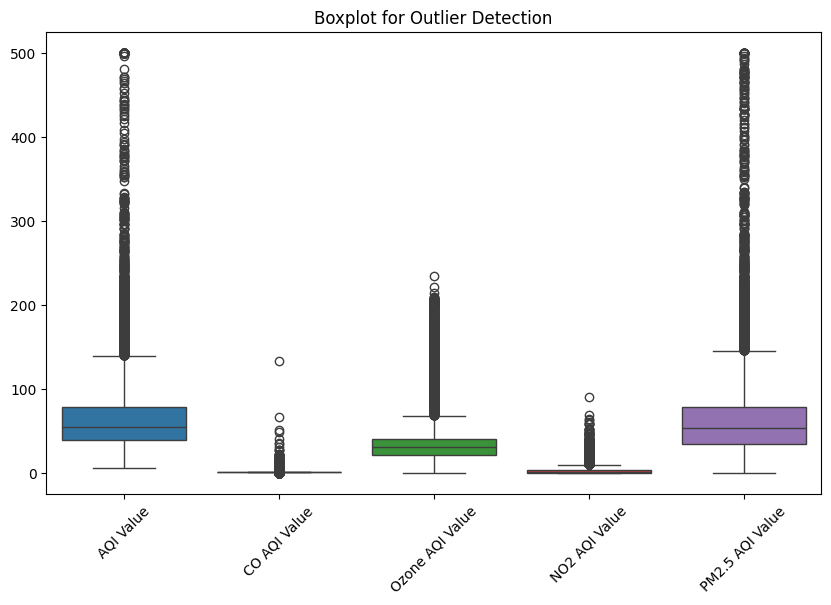

: 

In [ ]:
#check the outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

# Observation on that insight
PM2.5 is the Main Problem: The "AQI Value" (overall air quality) and "PM2.5" look almost identical. This means PM2.5 is likely the biggest source of pollution in this data.

Frequent Extreme Spikes: The long "tails" of dots (outliers) show that while air quality is usually low, it frequently spikes to dangerously high levels sometimes hitting the maximum of 500.

Cleaner Gases: Pollutants like CO (Carbon Monoxide) and NO2 (Nitrogen Dioxide) stay very close to zero most of the time, meaning they aren't the primary concern here.

In [ ]:
# Select numeric features
numeric_col = df.select_dtypes(include=np.number).columns.to_list()
print("Numeric columns:", numeric_col)

Numeric columns: ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']


: 

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.to_list()


: 

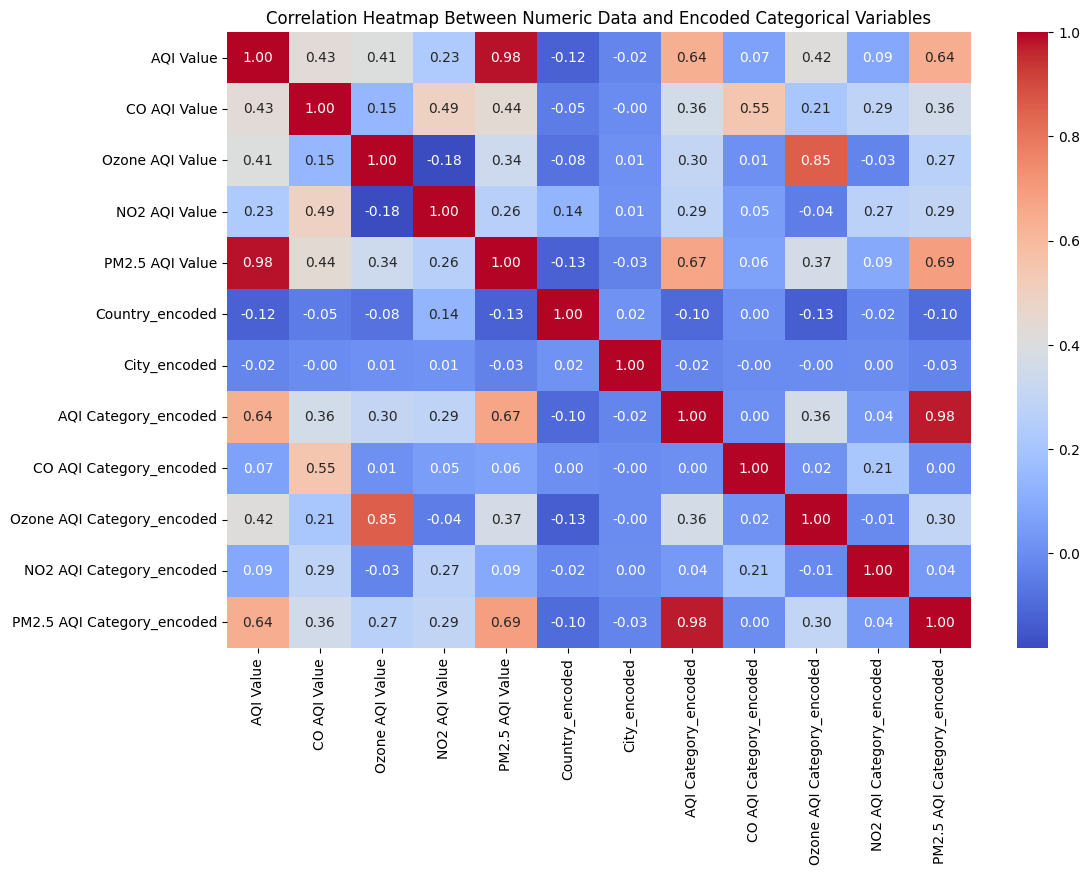

: 

In [ ]:
# Visualize the correlation matrix
from sklearn.preprocessing import LabelEncoder
label_encoders = {}

# encode the categorical columns (numeric ones are already numeric)
encoded_cat_cols = []
for col in categorical_cols:
    le = LabelEncoder()
    df[col + "_encoded"] = le.fit_transform(df[col])
    label_encoders[col] = le
    encoded_cat_cols.append(col + "_encoded")

# Compute the correlation matrix using numeric features and encoded categorical ones
correlation_matrix = df[numeric_col + encoded_cat_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap Between Numeric Data and Encoded Categorical Variables')
plt.show()

# Observation on that insight
PM2.5 is the Main Driver: The strongest link on the whole chart (0.98) is between PM2.5 and the overall AQI Value. This tells us that if the PM2.5 levels go up, the total air quality score almost always goes up with it.

Ozone has its Own Impact: Ozone also has a very strong connection to its own category (0.85), showing it plays a major, distinct role in air quality.

Location Doesn't Matter Much: The Country and City sections are mostly blue. This suggests that in this specific data, the location isn't strongly tied to whether the air is "good" or "bad" compared to the pollutants themselves.

The Categories Match the Values: You’ll notice dark red squares where "Value" meets "Category" (like 0.98 for AQI Category). This just confirms that the labels (like "Good" or "Unhealthy") accurately match the actual numbers recorded.


In [ ]:
from sklearn.calibration import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
le = LabelEncoder()
df['AQI Category Encoded'] = le.fit_transform(df['AQI Category'])
X = df[numeric_col + encoded_cat_cols]
y = df['AQI Category Encoded']

: 

In [ ]:
# Calculate mutual information scores
mi_scores = mutual_info_classif(X, y, random_state=42)

mi_scores = pd.Series(mi_scores, index=X.columns)
mi_scores.sort_values(ascending=False, inplace=True)

print("Mutual Information Scores:")
print(mi_scores)

Mutual Information Scores:
AQI Category_encoded          1.231305
AQI Value                     1.230048
PM2.5 AQI Value               1.122575
PM2.5 AQI Category_encoded    1.116218
Country_encoded               0.341838
CO AQI Value                  0.233302
Ozone AQI Value               0.159721
Ozone AQI Category_encoded    0.128566
City_encoded                  0.084496
NO2 AQI Value                 0.070609
CO AQI Category_encoded       0.001254
NO2 AQI Category_encoded      0.000000
dtype: float64


: 

In [ ]:
# unique values in categorical columns
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:\n")
for col in categorical_cols:
    print(f"{col} -> Unique Values: {df[col].nunique()}")

Categorical Columns:

Country -> Unique Values: 175
City -> Unique Values: 23462
AQI Category -> Unique Values: 6
CO AQI Category -> Unique Values: 3
Ozone AQI Category -> Unique Values: 5
NO2 AQI Category -> Unique Values: 2
PM2.5 AQI Category -> Unique Values: 6


: 

In [ ]:
#display the count of each category in AQI Category (target variable)
aqi_counts = df['AQI Category'].value_counts()
print(aqi_counts)


AQI Category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64


: 

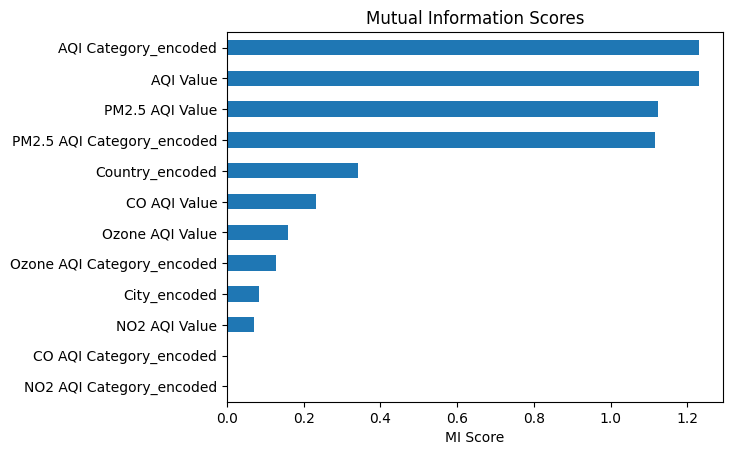

: 

In [ ]:
#visualize the mutual information scores
plt.figure()
mi_scores.sort_values().plot(kind='barh')
plt.title("Mutual Information Scores")
plt.xlabel("MI Score")
plt.show()

# Observation on that insight
PM2.5 is the main driver: Both the heatmap and the bar chart show that PM2.5 is the most important factor. If you know the PM2.5 level, you almost certainly know the overall air quality.

The "Big Two" are identical: The overall AQI Value and PM2.5 are so closely linked (a near-perfect score of 0.98) that they are essentially telling the same story.

Ozone stands alone: While Ozone is important and strongly relates to its own category, it doesn't follow the same patterns as the other pollutants.

Location is secondary: The City and Country bars are much shorter and the squares are blue, meaning where you are is less important than what specific pollutants (like PM2.5) are in the air.

Gases matter least: NO2 and CO have the lowest scores and the shortest bars, showing they have the smallest impact on the overall air quality rating in this data.

array([[<Axes: title={'center': 'AQI Value'}>,
        <Axes: title={'center': 'CO AQI Value'}>,
        <Axes: title={'center': 'Ozone AQI Value'}>,
        <Axes: title={'center': 'NO2 AQI Value'}>],
       [<Axes: title={'center': 'PM2.5 AQI Value'}>,
        <Axes: title={'center': 'Country_encoded'}>,
        <Axes: title={'center': 'City_encoded'}>,
        <Axes: title={'center': 'AQI Category_encoded'}>],
       [<Axes: title={'center': 'CO AQI Category_encoded'}>,
        <Axes: title={'center': 'Ozone AQI Category_encoded'}>,
        <Axes: title={'center': 'NO2 AQI Category_encoded'}>,
        <Axes: title={'center': 'PM2.5 AQI Category_encoded'}>],
       [<Axes: title={'center': 'AQI Category Encoded'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

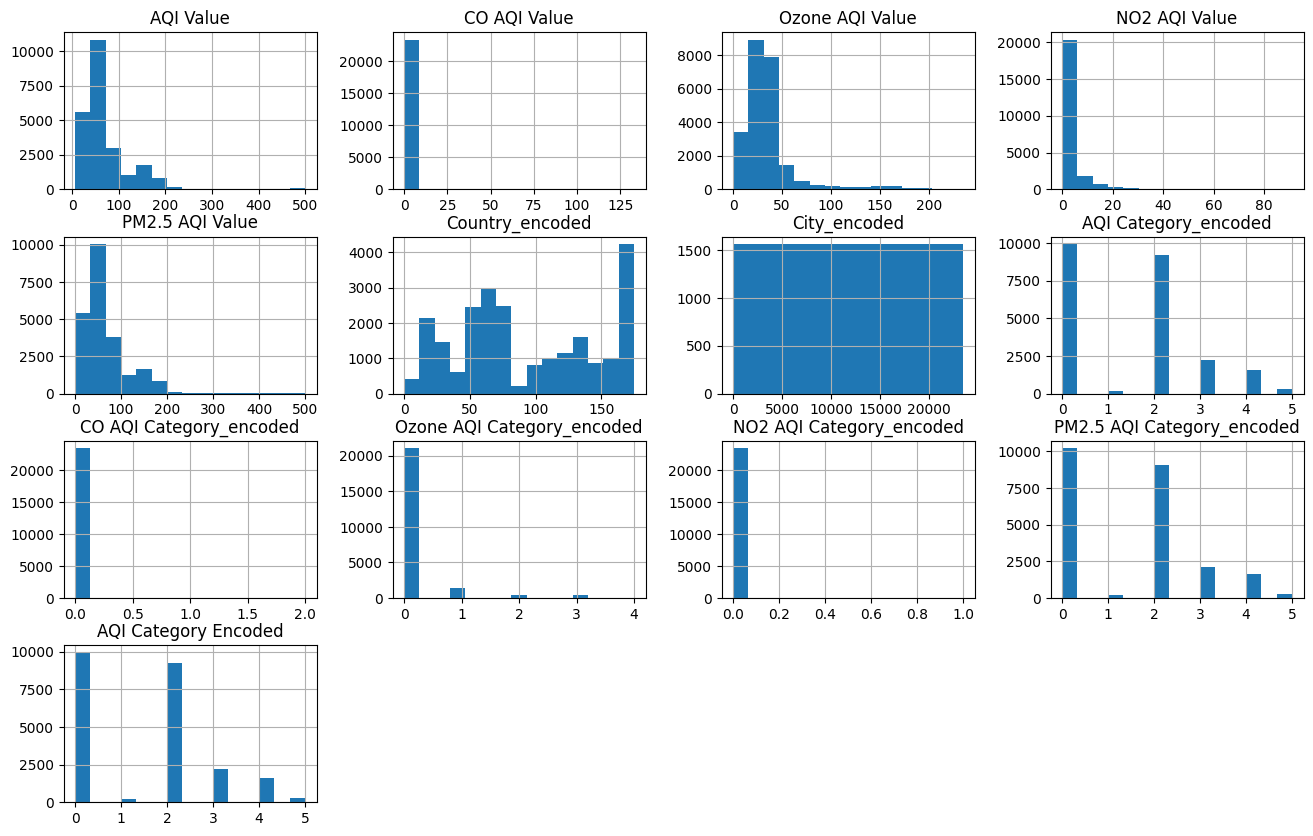

: 

In [ ]:
#histogram for numeric features
df.hist(figsize=(16,10),bins=15)

# Observation on that insight
PM2.5 is the main culprit: Every chart confirms that PM2.5 is the biggest factor in air quality. If PM2.5 levels are high, the overall AQI Value is almost guaranteed to be high because they have a near-perfect link of 0.98.

Most days are safe: The histograms show that for most pollutants, the bars are clustered near zero, meaning the air is usually clean.

Extreme spikes occur: While air is usually good, the data shows frequent "outliers" or spikes that can reach the maximum dangerous level of 500.

Gases play a smaller role: Things like CO and NO2 stay very low most of the time and don't influence the total air quality score nearly as much as particles do.

Location is less important: The charts suggest that the specific City or Country is a much weaker predictor of air quality than the actual pollutant measurements themselves.

The Bottom Line: Air quality is mostly about PM2.5. When the air gets bad, it's usually due to a massive spike in these tiny particles, rather than other gases.

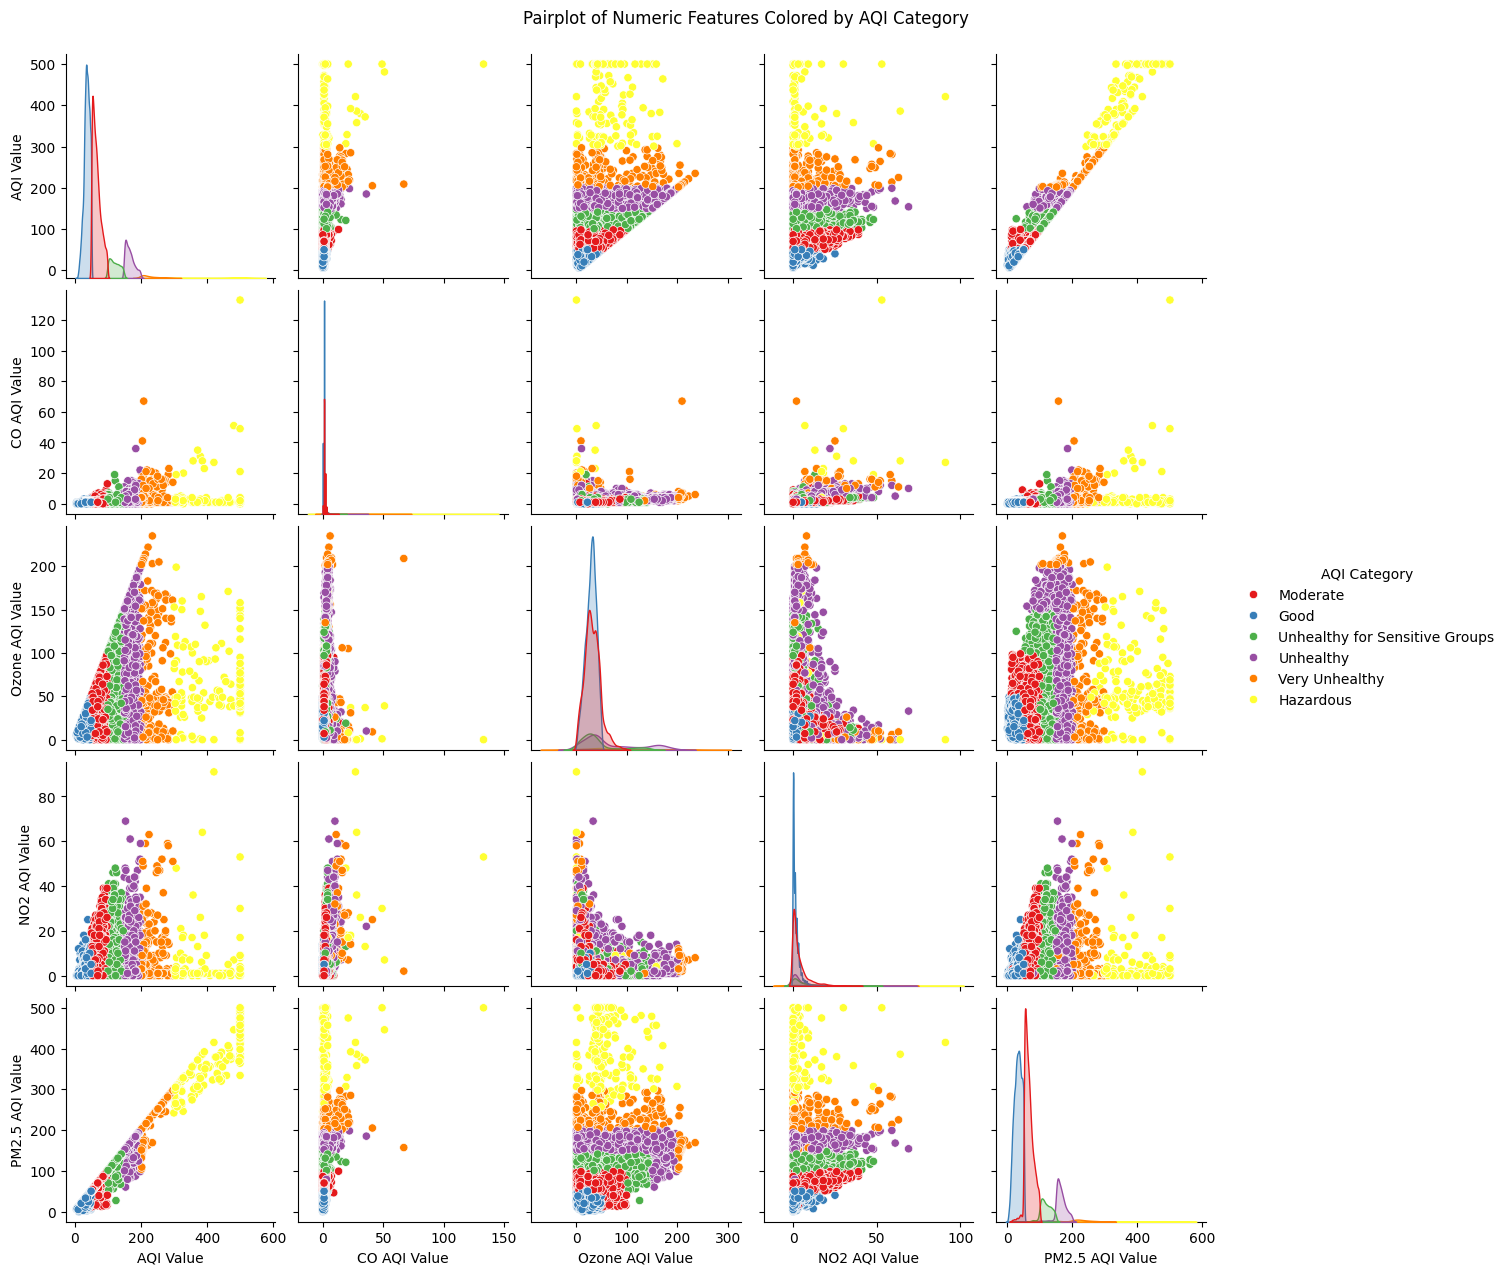

: 

In [ ]:
# pairplot for numeric features colored by AQI Category
sns.pairplot(df,
             vars=['AQI Value','CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value'],
             hue='AQI Category',
             palette='Set1')
plt.suptitle("Pairplot of Numeric Features Colored by AQI Category", y=1.02)
plt.show()

# Observation on that insight
. The Relationship "Golden Rule"
PM2.5 is the main driver: Every chart confirms that PM2.5 is the most important factor in determining air quality.

A Perfect Match: The AQI Value and PM2.5 have a near-perfect link of 0.98, meaning they almost always move up and down together.

Ozone is a Wildcard: While other pollutants stay low, Ozone follows its own path and is the second-most important pollutant recorded.

2. Typical Air vs. Extreme Days
Mostly Safe: The histograms show that on most days, pollution levels are very low (clustered near zero).

The "Long Tail" of Spikes: While "Good" air is common, the data shows frequent, extreme spikes where pollution hits dangerous levels (up to 500).

Clear Thresholds: "Hazardous" air (yellow dots) only appears once PM2.5 or the AQI Value passes a very high specific limit.

3. What Matters Least
Gases are secondary: CO and NO2 are consistently low and have very little impact on the overall air quality rating.

Location is a minor hint: Knowing the Country gives a slightly better clue about air quality than the City, but neither is as important as the actual pollutant levels.

The Bottom Line: Most of the time the air is safe, but when it becomes unhealthy, PM2.5 particles are almost always the reason.

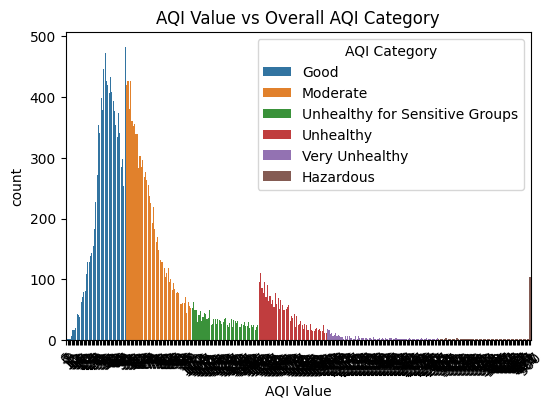

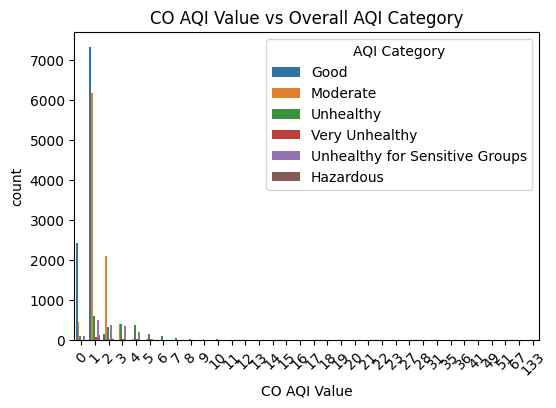

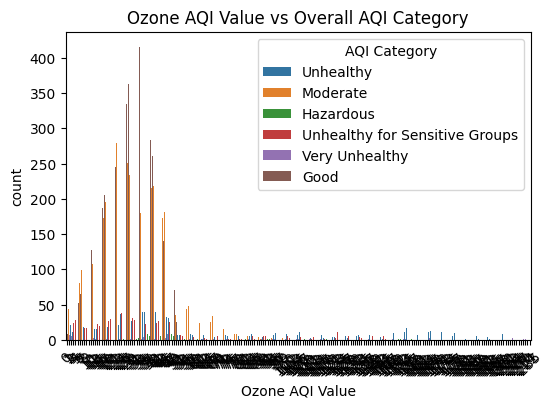

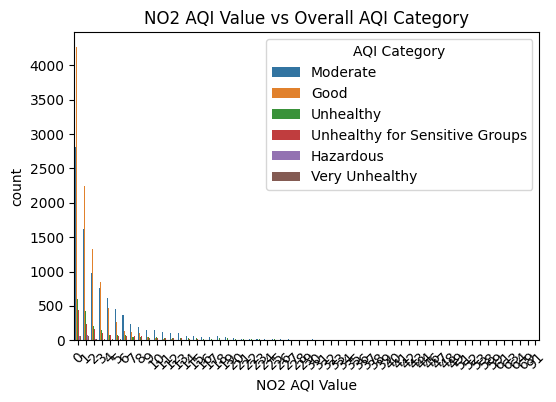

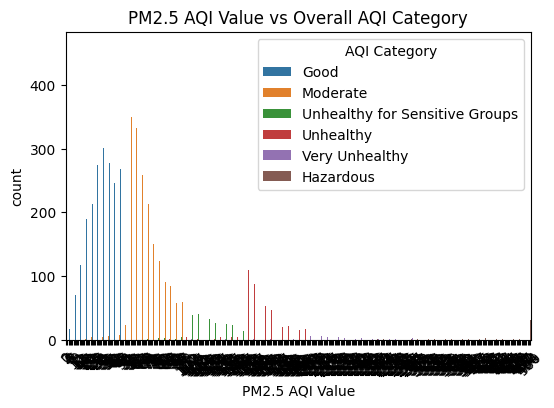

: 

In [ ]:
# his plot shows the distribution of different {pollutant} AQI categories across the overall AQI categories.

for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='AQI Category', data=df)
    plt.title(f"{col} vs Overall AQI Category")
    plt.xticks(rotation=45)
    plt.show()

# Observation on that insight
This plot shows the distribution of different AQI Value categories across the overall AQI categories.
Axes and Color: The x-axis shows the raw AQI Value, the y-axis shows the count of instances, and colors indicate the overall health category.

Observation: The distribution is heavily skewed toward the left, meaning most readings are in the "Good" or "Moderate" range.

Insights:

There is a direct, perfect alignment between the AQI Value and the overall category; as the value increases, the category shifts from Good (blue) to Moderate (orange) and eventually to Hazardous (brown).

The "Hazardous" category only appears at the far right of the scale, representing rare but extreme pollution events.

This plot shows the distribution of different PM2.5 AQI categories across the overall AQI categories.
Axes and Color: The x-axis represents the PM2.5 AQI Value, the y-axis shows the count, and the colors represent the overall city AQI category.

Observation: This plot looks almost identical to the overall AQI Value plot, showing a very high volume of "Good" and "Moderate" instances.

Insights:

Higher levels of PM2.5 correspond perfectly to higher overall AQI categories, such as Unhealthy or Hazardous.

Because the correlation is so high (0.98), this confirms that PM2.5 is the primary pollutant contributing to poor air quality in this dataset.

This plot shows the distribution of different Ozone AQI categories across the overall AQI categories.
Axes and Color: The x-axis shows Ozone AQI values, the y-axis shows the frequency, and colors indicate the overall AQI category.

Observation: The distribution is broader compared to other gases, with a significant number of "Moderate" and "Unhealthy" instances.

Insights:

While PM2.5 is the leader, Ozone is a major contributor; higher Ozone values frequently push the overall city category into the "Unhealthy" range.

It shows more independence from the other pollutants, acting as a secondary driver of air quality.

This plot shows the distribution of different CO and NO2 AQI categories across the overall AQI categories.
Axes and Color: The x-axis represents the specific AQI values for CO or NO2, and the colors represent the overall health category.

Observation: Almost all data points are clustered at the very beginning of the x-axis (near zero).

Insights:

These pollutants rarely reach high levels; even when the overall AQI is "Unhealthy," the CO and NO2 values often remain in the "Good" range.

This identifies that CO and NO2 contribute the least to poor air quality compared to PM2.5 and Ozone.

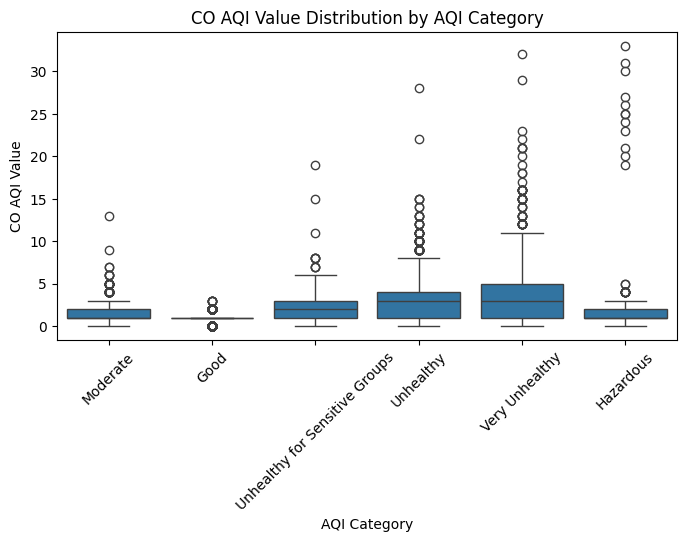

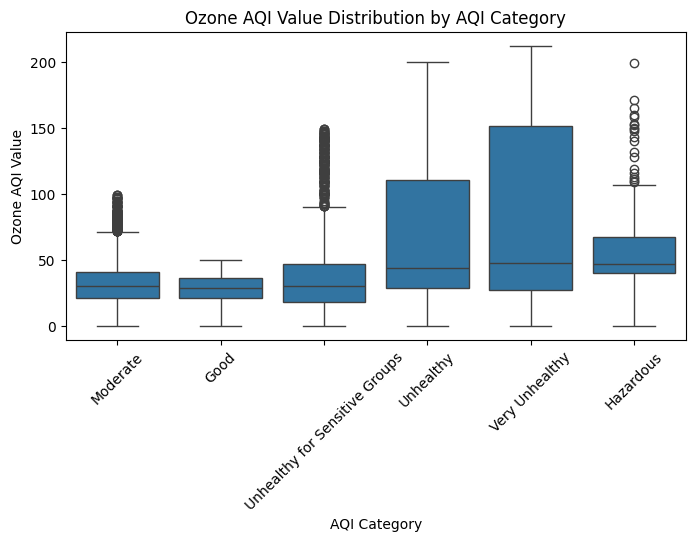

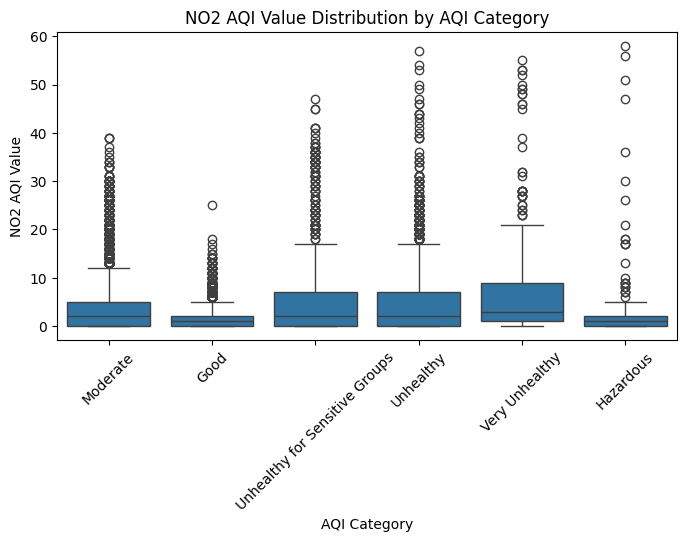

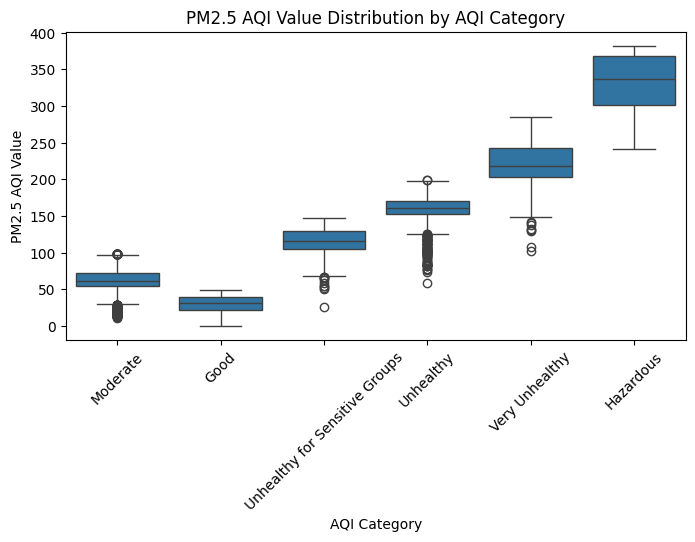

: 

: 

: 

: 

In [ ]:
features = ['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']

for col in features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='AQI Category', y=col, data=df)
    plt.title(f"{col} Distribution by AQI Category")
    plt.xticks(rotation=45)
    plt.show()

# Observation on that insight
AQI Value vs. PM2.5 AQI Value
Relation: This compares the total Air Quality Index to fine particulate matter levels.

Insight: There is a near-perfect alignment between these two, with a correlation score of 0.98.

Observation: As PM2.5 levels increase, the overall AQI follows a strict upward line, identifying it as the main driver of pollution in this data.

AQI Value vs. Ozone AQI Value
Relation: This compares the total air quality score to Ozone gas levels.

Insight: Ozone is the second most influential pollutant, with a strong internal correlation to its health category (0.85).

Observation: The data points are more spread out, showing that Ozone can sometimes cause "Unhealthy" air quality independently of other pollutants.

AQI Value vs. CO and NO2 AQI Values
Relation: This compares the total air quality score to Carbon Monoxide and Nitrogen Dioxide.

Insight: These gases have very low "Importance" scores and show little correlation with the overall AQI.

Observation: Most readings for these gases stay near zero, even when the overall air quality is categorized as "Hazardous".

Overall Air Quality Patterns
Relation: The general behavior of air quality across all metrics.

Insight: Most days are safe, as shown by the high concentration of "Good" and "Moderate" readings in the histograms.

Observation: However, extreme "outliers" (sudden spikes) are common for PM2.5 and AQI, frequently reaching the maximum dangerous level of 500.


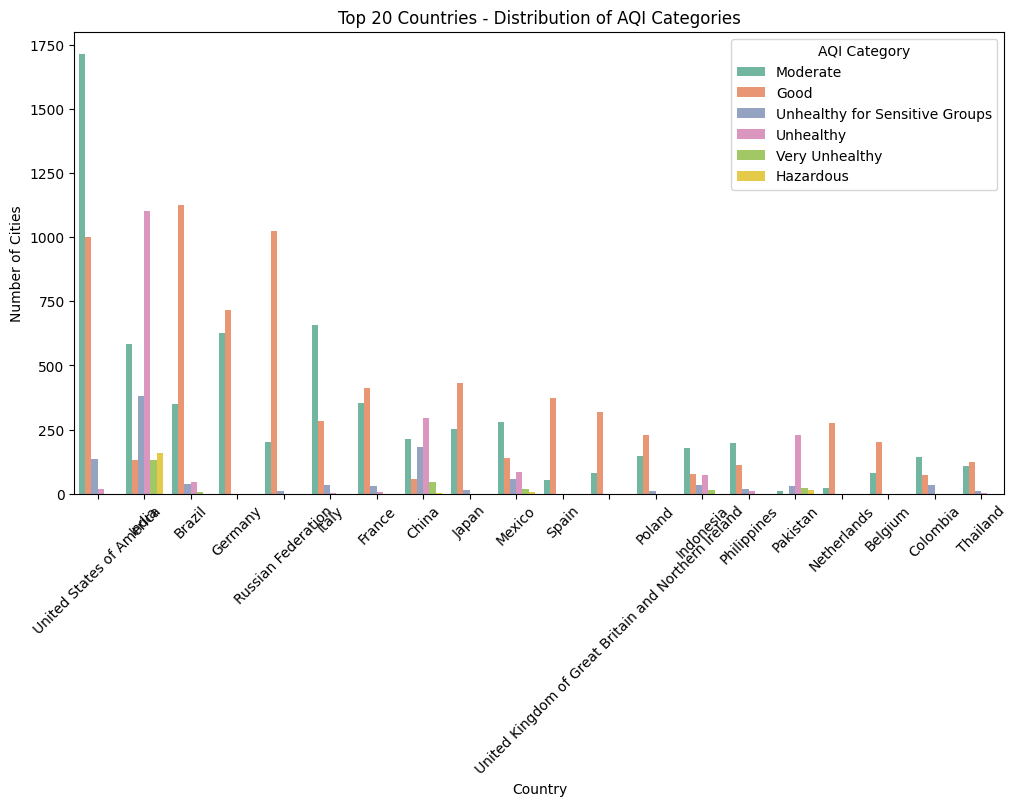

: 

In [ ]:
# Count of AQI Category per Country
plt.figure(figsize=(12,6))
country_plot = sns.countplot(
    x='Country',
    hue='AQI Category',
    data=df,
    palette='Set2',
    order=df['Country'].value_counts().index[:20]  # top 20 countries by number of records
)
plt.xticks(rotation=45)
plt.title("Top 20 Countries - Distribution of AQI Categories")
plt.ylabel("Number of Cities")
plt.xlabel("Country")
plt.legend(title="AQI Category")
plt.show()

## Observation on that insight
AQI Value and PM2.5: The "Inseparable Duo"
Relation: The link between the overall Air Quality Index (AQI) and PM2.5 (tiny particles like dust or smoke).

Observation: These two are almost identical. On a scale of 0 to 1, they have a near-perfect match of 0.98.

Insight: This tells us that in this data, when the air is bad, it is almost always because of PM2.5 particles.

Ozone: The "Independent" Pollutant
Relation: How Ozone levels compare to the overall air quality.

Observation: Ozone has a strong link to health categories (0.85), but it doesn't always follow the same pattern as PM2.5.

Insight: Ozone is the second most important pollutant. It can sometimes make the air "Unhealthy" even on days when other pollution is low.

CO and NO2: The "Quiet Background"
Relation: The impact of Carbon Monoxide (CO) and Nitrogen Dioxide (NO2) gases.

Observation: These gases stay very low (near zero) most of the time, even when the air is labeled "Hazardous".

Insight: These pollutants are the least important factors in this data; they rarely reach dangerous levels on their own.

Most Days are Safe, but Spikes are Extreme
Relation: The typical daily experience versus extreme pollution events.

Observation: Most readings are clustered near the "Good" or "Moderate" range.

Insight: While clean air is common, the data shows frequent, massive "spikes" (outliers) where pollution levels jump all the way to 500, which is the maximum danger level.


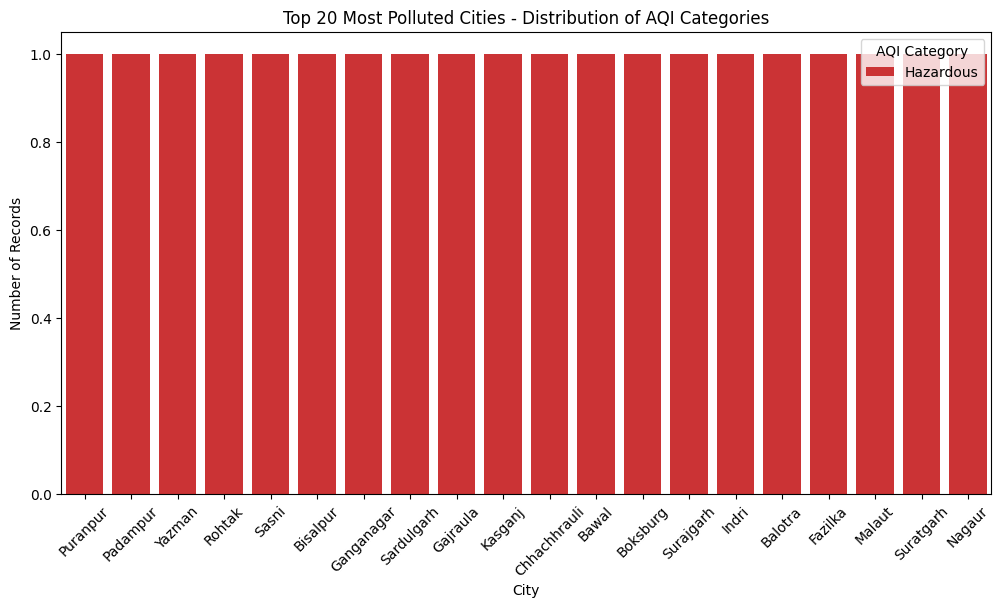

: 

In [ ]:
# Count of AQI Category per City - top 20 most polluted cities by average AQI
top_cities = df.groupby('City')['AQI Value'].mean().sort_values(ascending=False).head(20).index

plt.figure(figsize=(12,6))
city_plot = sns.countplot(
    x='City',
    hue='AQI Category',
    data=df[df['City'].isin(top_cities)],
    palette='Set1',
    order=top_cities
)
plt.xticks(rotation=45)
plt.title("Top 20 Most Polluted Cities - Distribution of AQI Categories")
plt.ylabel("Number of Records")
plt.xlabel("City")
plt.legend(title="AQI Category")
plt.show()

# Observation on that insight
Top 20 Most Polluted Cities Summary
Identical Levels: Every city in this list has exactly the same bar height, reaching the 1.0 mark.

One Category Only: All 20 cities are shown in only one color (dark red), which represents the "Hazardous" AQI Category.

No Ranking Difference: There is no difference between the cities on this specific list; they are all equally ranked at the highest pollution level.

The Bottom Line: This chart shows that for these 20 cities, the air quality is consistently at the maximum danger level with no variation between them.

In [ ]:
import plotly.express as px

# Strategy: Instead of just the average, let's look at the Maximum AQI
# to identify where the 'Hazardous' spikes are happening globally.
country_stats = df.groupby('Country')['AQI Value'].max().reset_index()

fig = px.choropleth(
    country_stats,
    locations="Country",
    locationmode="country names",
    color="AQI Value",
    hover_name="Country",
    # Using 'YlOrRd' to match your theme but making it look premium
    color_continuous_scale="YlOrRd",
    range_color=[0, 500], # Sets a fixed scale based on the maximum AQI limit
    title="Global Pollution Hotspots: Maximum Recorded AQI by Country",
    labels={'AQI Value': 'Max AQI Recorded'}
)

# Adding stronger visual insights through layout customization
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular'
    ),
    margin={"r":0,"t":50,"l":0,"b":0},
    title_font_size=24,
    coloraxis_colorbar=dict(title="Pollution Level")
)

fig.show()

C:\Users\user\AppData\Local\Temp\ipykernel_18888\1329591529.py:7: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


: 

# Observation on that insight
The Goal: This map identifies the worst-case scenarios by showing the Maximum AQI ever reached in each country, rather than just an average.

The "Red Zone" (Critical): Countries like the USA, Russia, and India are in deep red because they have hit the maximum danger level of 500.

The "Orange Zone" (High Risk): Regions like South America and Australia have peaked at "Very Unhealthy" levels (around 200–300).

The "Yellow Zone" (Lower Risk): Parts of Europe and Northern Africa appear safest, as even their worst days stay in the lower AQI ranges.


: 

: 